# Understanding age and cytomegalovirus signals in human immune cells with sample representation

In this tutorial, we will use blood immune single-cell data from the Dynamics of Immune Health and Age study (Nature 2025, [PMID 41162704](https://pubmed.ncbi.nlm.nih.gov/41162704/)). Donors vary in age and cytomegalovirus (CMV) status; cells are annotated with Allen Institute AIFI labels at several resolutions. 

Ideas here are based on the R package SETA: https://github.com/CellDiscoveryNetwork/SETA

Download `human_immune_health_atlas_full.h5ad` from the Immune Health Atlas catalog:
https://apps.allenimmunology.org/aifi/resources/imm-health-atlas/downloads/scrna/

Direct link to the full object (on the order of 40 GB) - clicking starts download!:
https://allenimmunology.org/public/publication/download/84792154-cdfb-42d0-8e42-39e210e980b4/filesets/568ad40c-516a-4646-9426-bdcd7029c1f5/human_immune_health_atlas_full.h5ad

Notebook is also based on https://carmonalab.github.io/scECODA_demo/Case_Study_1.html

## Cell type composition for efficient and biologically-grounded sample representation

Because this dataset is very large, we benchmark methods that are highly efficient. Compositions are perfect for rapid exploratory sample level analysis, and are directly tied to biology. `patpy` provides a simple interface to cell type composition-based representations with centered-log ratio (CLR) transform via `CellGroupComposition(apply_clr=True)`. The other methods in the benchmark use the same label column but aggregate cells in different ways


## Install patpy


In [1]:
# !pip install git+https://github.com/lueckenlab/patpy.git@main
# !pip install -q pilotpy


## Import packages


In [6]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib

import patpy

warnings.filterwarnings("ignore", category=UserWarning)


## Read the data

Set `ADATA_PATH` to your local `human_immune_health_atlas_full.h5ad`. The object should have `obsm['X_pca']` (used by pseudobulk-style methods).


In [3]:
ADATA_PATH = "/Users/kylekimler/Projects/patient-maps-playground/data/human_immune_health_atlas_full.h5ad"


In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 1821725 × 1236
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'seurat.

## Benchmark

To understand which sample representation method better reflects biological information, we will run a small benchmark using `patpy`. We will compare:
- Pseudobulk
- Pseudobulk per cell type (`GroupedPseudobulk`)
- Composition
- Optimal transport-based method PILOT
- Random baseline

We will evaluate preservation of biological effects and mixing of batches with prediction from nearest neighbors. See the [benchmarking tutorial](https://patpy.readthedocs.io/en/latest/tutorials/notebooks/benchmarking_sample_representation_methods.html) for more information. Briefly, we need to classify sample-level covariates into biologically **relevant** and **technical**. We will then plot summarised prediction/mixing quality results.

This loop reuses the same `adata`; if you hit odd state, restart from a fresh `read_h5ad`. **PILOT** can be slow on the full atlas; reduce cells or samples if needed.


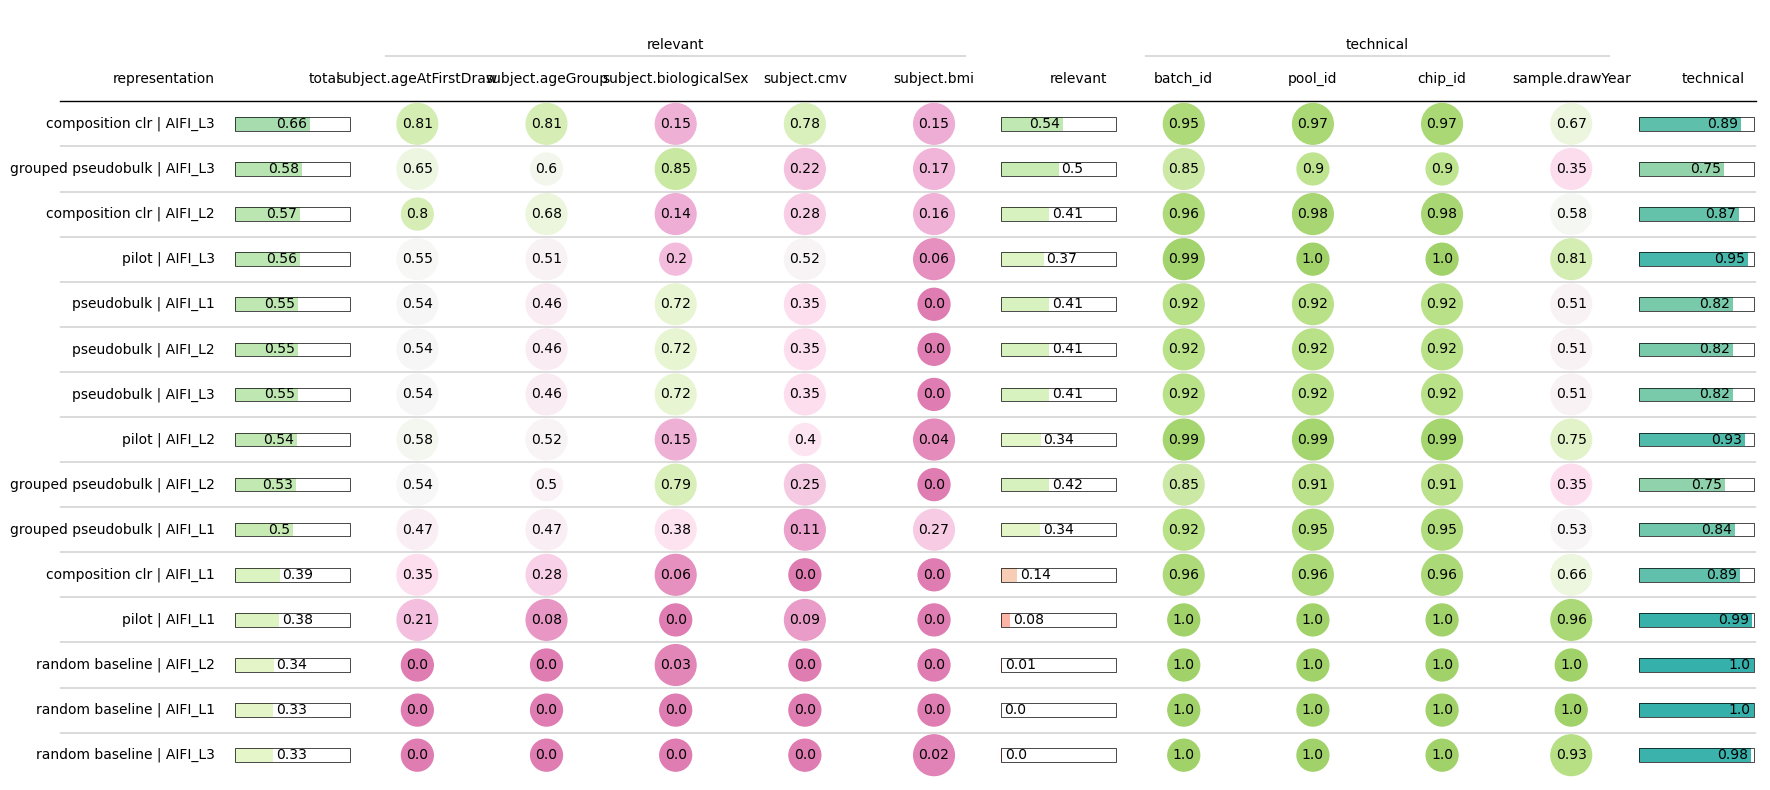

In [7]:
SAMPLE_KEY = "sample.sampleKitGuid"
LABEL_RESOLUTIONS = ["AIFI_L1", "AIFI_L2", "AIFI_L3"]
# PILOT expects a per-cell status column
PILOT_SAMPLE_STATE_COL = "subject.cmv"
# Columns used only for UMAP coloring below
AGE_COL = "subject.ageAtFirstDraw"
CMV_COL = "subject.cmv"
RNG = 67
N_NEIGHBORS = 7


# KNN tasks per covariate; "relevant" = biological, "technical" = batch / processing
BENCHMARK_SCHEMA = {
    "relevant": {
        "subject.ageAtFirstDraw": "regression",
        "subject.ageGroup": "classification",
        "subject.biologicalSex": "classification",
        "subject.cmv": "classification",
        "subject.bmi": "regression",
    },
    "technical": {
        "batch_id": "classification",
        "pool_id": "classification",
        "chip_id": "classification",
        "sample.drawYear": "regression",
    },
}

REQ_OBS = (
    {SAMPLE_KEY, CMV_COL, AGE_COL, *LABEL_RESOLUTIONS}
    | {c for bucket in BENCHMARK_SCHEMA.values() for c in bucket}
)

for col in REQ_OBS:
    assert col in adata.obs, col
assert "X_pca" in adata.obsm, "need X_pca in obsm for pseudobulk methods"


def build_method(method: str, label_key: str):
    if method == "composition_clr":
        return patpy.tl.CellGroupComposition(SAMPLE_KEY, label_key, apply_clr=True, seed=RNG)
    if method == "pseudobulk":
        return patpy.tl.Pseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "grouped_pseudobulk":
        return patpy.tl.GroupedPseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "random_baseline":
        return patpy.tl.RandomVector(SAMPLE_KEY, label_key, latent_dim=32, seed=RNG)
    if method == "pilot":
        return patpy.tl.PILOT(
            SAMPLE_KEY,
            label_key,
            sample_state_col=PILOT_SAMPLE_STATE_COL,
            layer="X_pca",
            seed=RNG,
        )
    raise ValueError(method)


METHOD_ORDER = ["composition_clr", "pseudobulk", "grouped_pseudobulk", "pilot", "random_baseline"]

rows: list[dict] = []
for label_key in LABEL_RESOLUTIONS:
    for method in METHOD_ORDER:
        m = build_method(method, label_key)
        m.prepare_anndata(adata)
        force = method.startswith("composition") or method == "pilot"
        m.calculate_distance_matrix(force=force)
        for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
            for cov_col, task in cov_map.items():
                out = m.evaluate_representation(
                    cov_col, method="knn", n_neighbors=N_NEIGHBORS, task=task
                )
                rows.append(
                    {
                        "label_key": label_key,
                        "method": method,
                        "covariate": cov_col,
                        "covariate_type": covariate_type,
                        "task": task,
                        "score": out["score"],
                        "metric": out["metric"],
                    }
                )

benchmark_long = pd.DataFrame(rows)


def _plot_score(row: pd.Series) -> float:
    s = float(row["score"])
    if row["covariate_type"] == "technical":
        s = 1.0 - s
    if row["metric"] == "spearman_r":
        s = abs(s)
    return s


benchmark_long["plot_score"] = benchmark_long.apply(_plot_score, axis=1)

bio = benchmark_long[benchmark_long["covariate_type"] == "relevant"]
tech = benchmark_long[benchmark_long["covariate_type"] == "technical"]
summary = (
    bio.groupby(["label_key", "method"], as_index=False)["plot_score"]
    .mean()
    .rename(columns={"plot_score": "bio_mean"})
    .merge(
        tech.groupby(["label_key", "method"], as_index=False)["plot_score"]
        .mean()
        .rename(columns={"plot_score": "tech_mean"}),
        on=["label_key", "method"],
        how="outer",
    )
)
summary["mean_score"] = (summary["bio_mean"] + summary["tech_mean"]) / 2.0
results = summary.sort_values("mean_score", ascending=False).reset_index(drop=True)

knn_results_wide = benchmark_long.pivot_table(
    index=["method", "label_key"],
    columns="covariate",
    values="plot_score",
    aggfunc="first",
)

plot_df = knn_results_wide.reset_index()
plot_df["representation"] = plot_df["method"].str.replace("_", " ") + " | " + plot_df["label_key"]
plot_df = plot_df.drop(columns=["method", "label_key"]).set_index("representation")

for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
    tcols = list(cov_map.keys())
    plot_df[covariate_type] = plot_df[tcols].mean(axis=1)

clin_weight = 2 / 3
plot_df["total"] = clin_weight * plot_df["relevant"] + (1 - clin_weight) * plot_df["technical"]

cols_order = ["total"]
for covariate_type in BENCHMARK_SCHEMA:
    cols_order.extend(list(BENCHMARK_SCHEMA[covariate_type].keys()))
    cols_order.append(covariate_type)

cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#FF9693", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

col_defs: list = []
col_defs.append(
    ColumnDefinition(
        "total",
        width=0.7,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap,
            "plot_bg_bar": True,
            "annotate": True,
            "height": 0.5,
            "lw": 0.5,
            "formatter": lambda x: round(x, 2),
        },
    )
)

for covariate_type in BENCHMARK_SCHEMA:
    type_cols = list(BENCHMARK_SCHEMA[covariate_type].keys())
    for col in type_cols:
        col_defs.append(
            ColumnDefinition(
                name=col,
                width=0.75,
                formatter=lambda x: round(x, 2),
                textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
                cmap=normed_cmap(benchmark_long["plot_score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
                group=covariate_type,
            )
        )
    col_defs.append(
        ColumnDefinition(
            covariate_type,
            width=0.7,
            plot_fn=bar,
            plot_kw={
                "cmap": cmap,
                "plot_bg_bar": True,
                "annotate": True,
                "height": 0.5,
                "lw": 0.5,
                "formatter": lambda x: round(x, 2),
            },
        )
    )

fig, ax = plt.subplots(figsize=(22, 10))
Table(
    plot_df[cols_order].sort_values("total", ascending=False),
    column_definitions=tuple(col_defs),
    ax=ax,
)
plt.show()


We can see that CLR-transformed composition of high resolution (L3) labels achieves the best performance.

### A global coherence metric, PERMANOVA.
In compositional analysis of ecological and microbiome data, CLR is compared with PERMANOVA. It can be better than KNN in two situations: 
1. PERMANOVA provides a p-value metric through its permutational statistical test. 
2. PERMANOVA provides a *global* coherence metric (often plotted with 95% confidence ellipses around groups on embeddings), while the KNN better tracks local coherence in neighborhoods.

To compare these two metrics, we plot PERMANOVA with ellipses next to neighborhoods with the KNN metric.

**Left:** PCA of per-sample CLR compositions at **AIFI_L3**; **95%** bivariate normal confidence **ellipses** per **CMV** level (ordination ellipse style). An annotation box summarizes **PERMANOVA** (pseudo-F and permutation **p-value**) on the **same** Euclidean distance matrix used for CLR in patpy.

**Right:** Line segments connect each sample to its **k** nearest neighbors **in the full sample distance matrix**. An annotation box gives the **KNN** benchmark result for CMV (**k** matches `N_NEIGHBORS` above).


Ordination uses benchmark top CLR label: AIFI_L3 (mean_score=0.7149)


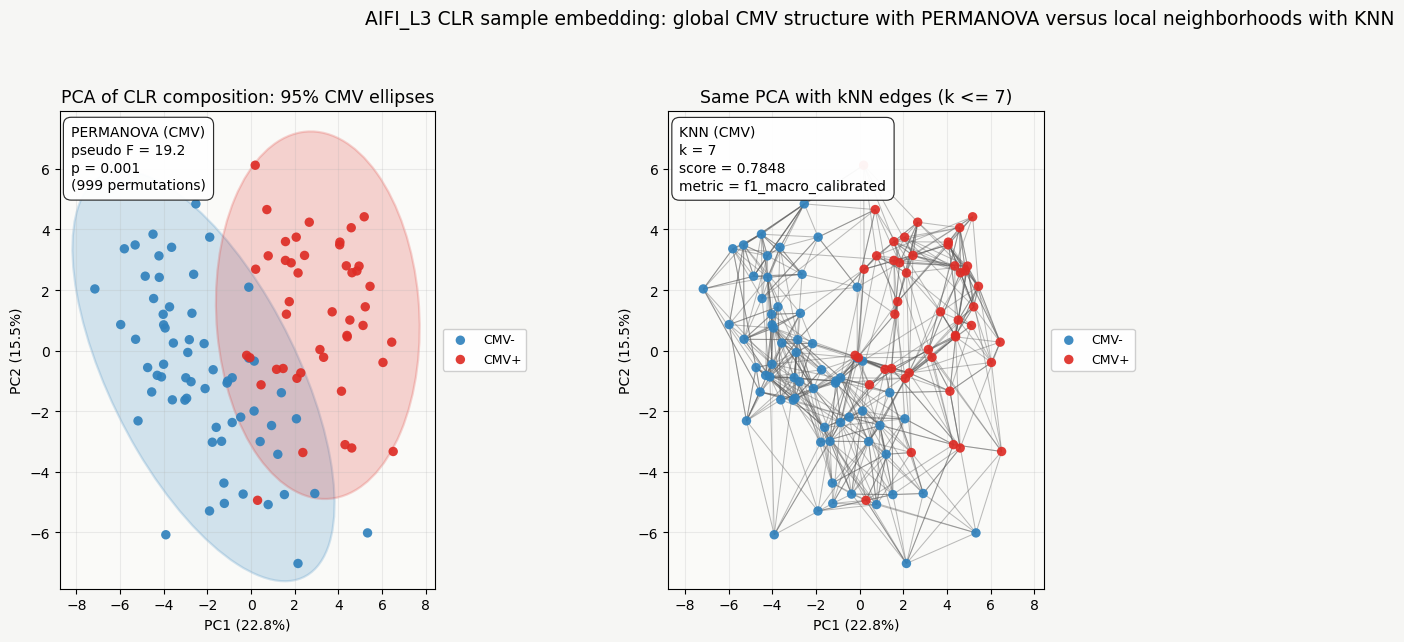

In [8]:
ELLIPSE_CHI2 = stats.chi2.ppf(0.95, 2)
PERMANOVA_PERMUTATIONS = 999
N_EDGE = min(N_NEIGHBORS, 12)
cmv_colors = color_cmv = {"CMV-": "#3182bd", "CMV+": "#de2d26"}


# Map raw CMV catalogue values (Negative / Positive / etc.) to CMV- / CMV+
def cmv_display(x):
    s = str(x).strip().upper()
    if "POS" in s or s in {"TRUE", "T", "1", "CMV+"}:
        return "CMV+"
    if "NEG" in s or s in {"FALSE", "F", "0", "CMV-"}:
        return "CMV-"
    return str(x)


# Pick the CLR resolution that scored best in the benchmark above
clr_top = (
    results.query("method == 'composition_clr'")
    .sort_values("mean_score", ascending=False)
    .iloc[0]
)
ORD_LABEL = str(clr_top["label_key"])
print(f"Ordination uses benchmark top CLR label: {ORD_LABEL} (mean_score={clr_top['mean_score']:.4f})")

# Create CLR compositional PCA with patpy for metric comparisons
m_ord = patpy.tl.CellGroupComposition(SAMPLE_KEY, ORD_LABEL, apply_clr=True, seed=RNG)
m_ord.prepare_anndata(adata)
D_ord = np.asarray(m_ord.calculate_distance_matrix(force=True), dtype=float)
X_ord = np.asarray(m_ord.sample_representation, dtype=float)

samples_ord = list(m_ord.sample_representation.index)
sample_table = adata.obs.drop_duplicates(subset=[SAMPLE_KEY], keep="first").set_index(SAMPLE_KEY)
cmv_ord = sample_table.loc[samples_ord, CMV_COL].map(cmv_display)
pca_ord = PCA(n_components=2, random_state=RNG)
XY_ord = pca_ord.fit_transform(X_ord)

# Call patpy evaluations (PERMANOVA and KNN metrics) to overlay on metric comparisons plots
perm_ord = m_ord.evaluate_representation(CMV_COL, method="permanova", permutations=PERMANOVA_PERMUTATIONS)
knn_ord = m_ord.evaluate_representation(CMV_COL, method="knn", n_neighbors=N_NEIGHBORS, task="classification")

# CMV levels present in the data, in canonical order
levels = [v for v in ("CMV-", "CMV+") if (cmv_ord == v).any()]


# Create a Chi squared ellipse to conceptualize PERMANOVA comparisons (https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html)
def ellipse(xy, **kw):
    if len(xy) < 3 or np.linalg.det(np.cov(xy.T)) < 1e-14:
        return None
    vals, vecs = np.linalg.eigh(np.cov(xy.T))
    order = np.argsort(vals)[::-1]
    vals, vecs = np.maximum(vals[order], 1e-12), vecs[:, order]
    w, h = 2 * np.sqrt(ELLIPSE_CHI2 * vals)
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    return Ellipse(xy.mean(0), w, h, angle=theta, **kw)


# Build kNN edges from the patpy distance matrix
D_nn = D_ord.copy()
np.fill_diagonal(D_nn, np.inf)
k_take = min(N_EDGE, max(D_nn.shape[0] - 1, 0))
edges = [(XY_ord[i], XY_ord[j]) for i, row in enumerate(D_nn) for j in np.argsort(row)[:k_take]]


# Annotations for comparisons plots to overlay metrics
def annot(ax, text):
    ax.text(
        0.03, 0.97, text, transform=ax.transAxes, va="top", ha="left",
        fontsize=10, linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, lw=0.85),
    )


fig, (ax_e, ax_g) = plt.subplots(1, 2, figsize=(20.5, 6.55), facecolor="#f6f6f4")
fig.subplots_adjust(wspace=0.62, left=0.10, right=0.58, top=0.84)
sc_kw = dict(s=46, alpha=0.92, edgecolors="none", zorder=3)

# Draw one 95% ellipse and matching scatter per CMV level
for lev in levels:
    pts = XY_ord[(cmv_ord == lev).to_numpy()]
    e = ellipse(pts, color=color_cmv[lev], alpha=0.2, lw=1.6, zorder=1)
    if e is not None:
        ax_e.add_patch(e)
    for ax in (ax_e, ax_g):
        ax.scatter(pts[:, 0], pts[:, 1], color=color_cmv[lev], label=lev, **sc_kw)
ax_g.add_collection(LineCollection(edges, colors="#5c5c5c", alpha=0.4, lw=0.75, zorder=0))

annot(ax_e, f"PERMANOVA (CMV)\npseudo F = {perm_ord['score']:.4g}\np = {perm_ord['p_value']:.4g}\n({PERMANOVA_PERMUTATIONS} permutations)")
annot(ax_g, f"KNN (CMV)\nk = {N_NEIGHBORS}\nscore = {knn_ord['score']:.4f}\nmetric = {knn_ord['metric']}")

pc_lab = [f"PC{i + 1} ({pca_ord.explained_variance_ratio_[i] * 100:.1f}%)" for i in (0, 1)]
ax_e.set_title("PCA of CLR composition: 95% CMV ellipses", fontsize=12.5)
ax_g.set_title(f"Same PCA with kNN edges (k <= {N_EDGE})", fontsize=12.5)
for ax in (ax_e, ax_g):
    ax.set(facecolor="#fafaf8", xlabel=pc_lab[0], ylabel=pc_lab[1])
    ax.grid(True, alpha=0.22)
    ax.legend(framealpha=0.94, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
ax_g.set_xlim(ax_e.get_xlim())
ax_g.set_ylim(ax_e.get_ylim())

fig.suptitle(
    f"{ORD_LABEL} CLR sample embedding: global CMV structure with PERMANOVA versus local neighborhoods with KNN",
    fontsize=13.5,
    y=0.995,
)
plt.show()


**Interpreting pseudo F**: pseudo F summarizes how much of the total variation lies between CMV groups versus within them. A pseudo F of 19.2, for example, means that the variation between groupings is 19.2 times larger than the variation among individual samples within those groups. Because pseudo F scales with sample size, absolute values are not directly comparable across datasets. Use the permutation p value as the formal significance test.


## Using compositional PCA to analyze scRNAseq patient groups

The CLR PCA winning the benchmark captures both age group and CMV status. 

Scatter plots by colour for CMV (values mapped to CMV- and CMV+) and by age group show this separation. Since this unbiased PCA separates these groups, we can simply look at compositional loadings to understand differences between groups.

Bar plots show the top five negative and positive PC loadings. 

The heatmap that follows is mean CLR for CMV+ minus CMV- within each age group. There are only 3 children with CMV+. Additionally, some cell types might not be present within each group. If at least 1 sample contains a cell type we plot it for that group here. This way we can see how CMV affects the immune compartment across age groups. 


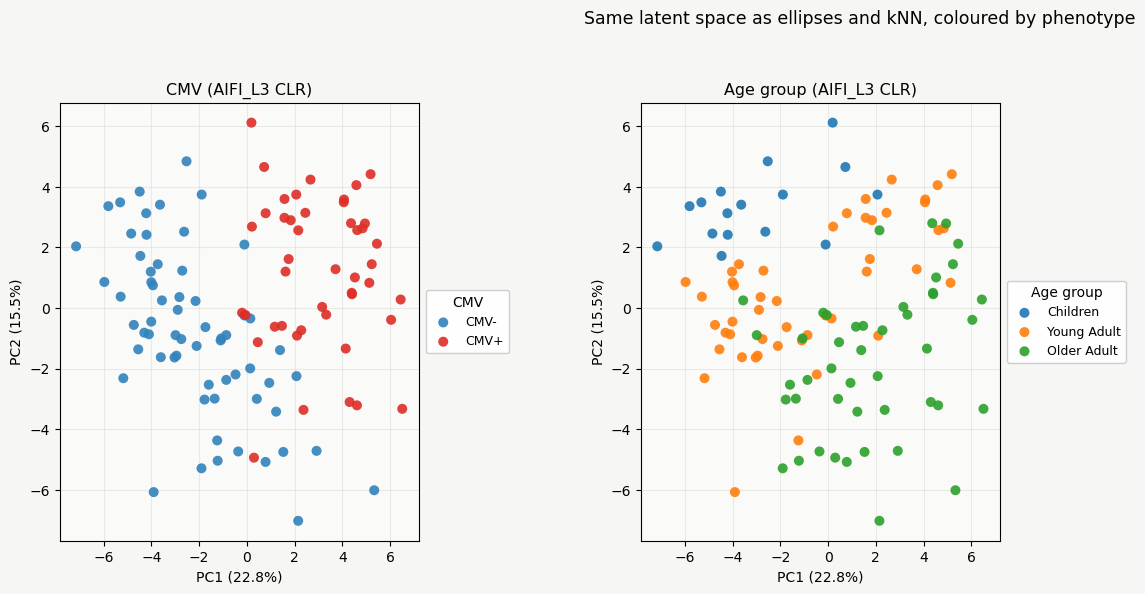

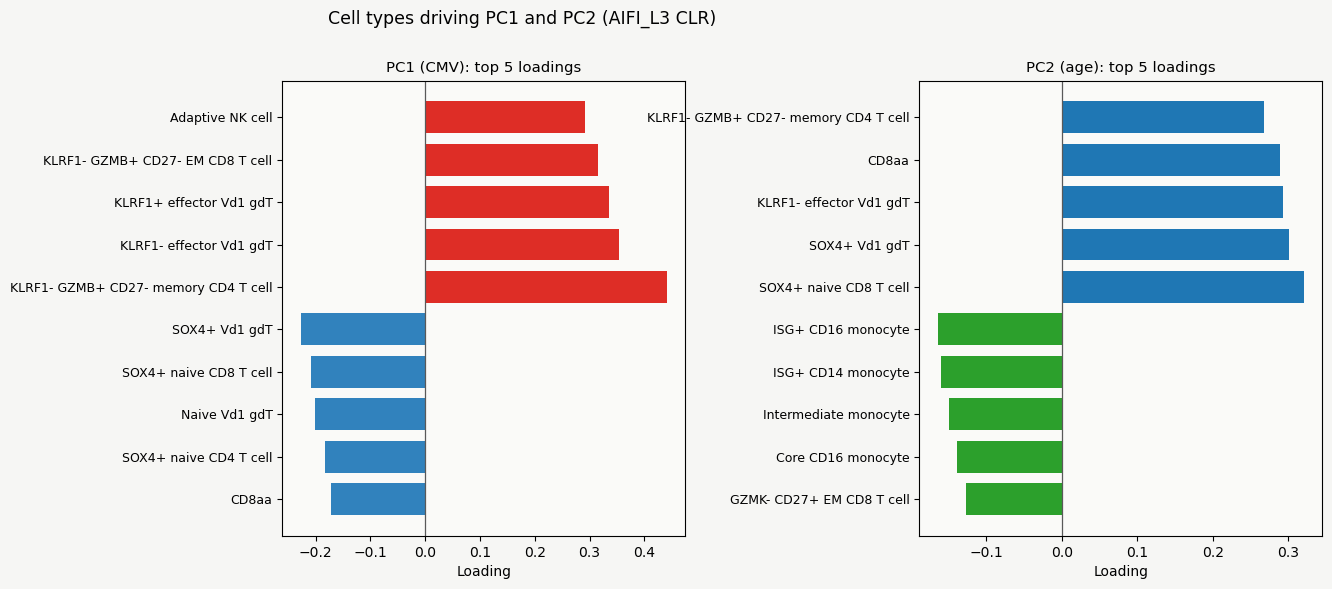

Samples per age group by CMV:
 CMV          CMV-  CMV+
age                    
Children       13     3
Older Adult    21    24
Young Adult    29    18


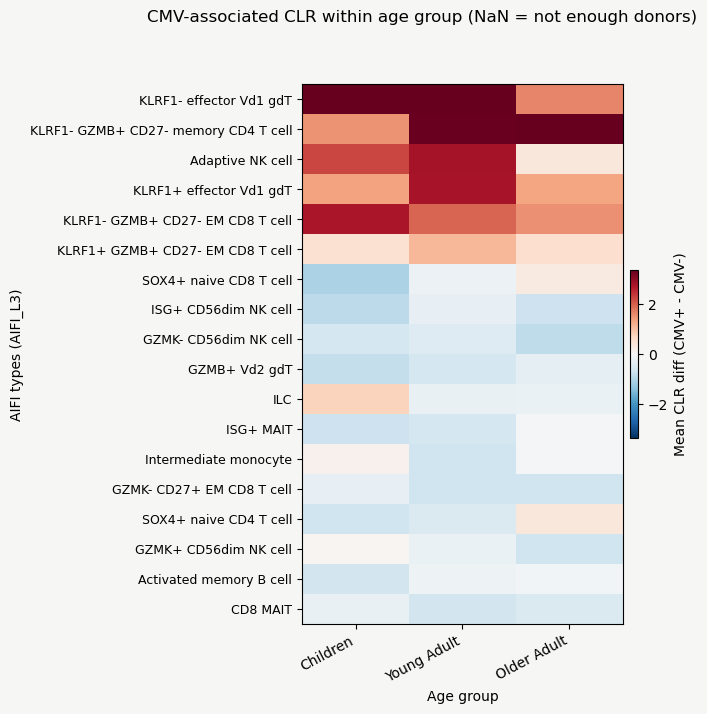

In [9]:
# Reuses XY_ord, pca_ord, X_ord, m_ord, samples_ord, cmv_ord, levels, color_cmv, cmv_colors from c-ord
cell_types = np.asarray(m_ord.sample_representation.columns.astype(str))
age_ord = sample_table.loc[samples_ord, "subject.ageGroup"].astype(str)

# Force the canonical age order Children, Young Adult, Older Adult
AGE_ORDER = ["Children", "Young Adult", "Older Adult"]
present = set(age_ord.unique())
age_levels = [a for a in AGE_ORDER if a in present] + sorted(present - set(AGE_ORDER))
age_palette = dict(zip(age_levels, plt.cm.tab10(np.linspace(0, 0.9, max(len(age_levels), 10)))))


# Scatter on the shared PC1 / PC2 coordinates, coloured by a categorical group
def scatter_groups(ax, group, palette):
    for k, col in palette.items():
        m = (group == k).to_numpy()
        ax.scatter(XY_ord[m, 0], XY_ord[m, 1], s=52, color=col, alpha=0.9,
                   edgecolors="none", label=str(k), zorder=3)


pc_lab = [f"PC{i + 1} ({pca_ord.explained_variance_ratio_[i] * 100:.1f}%)" for i in (0, 1)]

# Figure 1: same PCA, coloured by CMV (left) and by age group (right)
fig1, (ax_c, ax_a) = plt.subplots(1, 2, figsize=(20.0, 6.0), facecolor="#f6f6f4")
fig1.subplots_adjust(wspace=0.62, left=0.10, right=0.57, top=0.84)
scatter_groups(ax_c, cmv_ord, {lev: color_cmv[lev] for lev in levels})
scatter_groups(ax_a, age_ord, {ag: age_palette[ag] for ag in age_levels})
for ax, name in [(ax_c, "CMV"), (ax_a, "Age group")]:
    ax.set(facecolor="#fafaf8", xlabel=pc_lab[0], ylabel=pc_lab[1])
    ax.set_title(f"{name} ({ORD_LABEL} CLR)", fontsize=11.5)
    ax.grid(True, alpha=0.22)
    ax.legend(title=name, fontsize=9, title_fontsize=10, loc="center left",
              bbox_to_anchor=(1.02, 0.5), borderaxespad=0, frameon=True, framealpha=0.95)
ax_a.set_xlim(ax_c.get_xlim())
ax_a.set_ylim(ax_c.get_ylim())
fig1.suptitle("Same latent space as ellipses and kNN, coloured by phenotype", fontsize=12.5, y=0.995)
plt.show()

# Figure 2: top 5 negative and top 5 positive loadings for PC1 and PC2
TOP_K = 5
older = next((a for a in age_levels if "older" in a.lower()), None)
pc2_neg = age_palette.get(older, "#6A3D9A")
pc2_pos = age_palette.get("Children", "#FF7F00")


# Horizontal bars for the strongest negative and positive loadings on a PC
def loadings(ax, comp, neg_c, pos_c, title):
    order = np.argsort(comp)
    sel = np.r_[order[:TOP_K][::-1], order[-TOP_K:][::-1]]
    vals = comp[sel]
    ax.barh(np.arange(len(sel)), vals, color=[neg_c if v < 0 else pos_c for v in vals],
            height=0.75, edgecolor="none")
    ax.axvline(0, color="0.35", lw=0.9)
    ax.set_yticks(range(len(sel)))
    ax.set_yticklabels(cell_types[sel], fontsize=9)
    ax.set_xlabel("Loading")
    ax.set_title(title, fontsize=10.75)
    ax.set_facecolor("#fafaf8")


fig2, (ax_p1, ax_p2) = plt.subplots(1, 2, figsize=(20.0, 6.15), facecolor="#f6f6f4")
fig2.subplots_adjust(wspace=0.58, left=0.38, right=0.90, top=0.88, bottom=0.14)
loadings(ax_p1, pca_ord.components_[0], cmv_colors["CMV-"], cmv_colors["CMV+"], "PC1 (CMV): top 5 loadings")
loadings(ax_p2, pca_ord.components_[1], pc2_neg, pc2_pos, "PC2 (age): top 5 loadings")
fig2.suptitle(f"Cell types driving PC1 and PC2 ({ORD_LABEL} CLR)", fontsize=12.5, y=0.995)
plt.show()

# Figure 3: heatmap of mean CLR difference CMV+ minus CMV- per age group
v_lo, v_hi = "CMV-", "CMV+"
cmv_arr = cmv_ord.loc[samples_ord].values
age_arr = age_ord.values
print("Samples per age group by CMV:\n",
      pd.crosstab(pd.Series(age_arr, name="age"), pd.Series(cmv_arr, name="CMV")).to_string())

cols = []
for ag in age_levels:
    sel = age_arr == ag
    min_total, min_each = (4, 1) if ag == "Children" else (15, 5)
    cmv_s = cmv_arr[sel]
    if sel.sum() < min_total or (cmv_s == v_lo).sum() < min_each or (cmv_s == v_hi).sum() < min_each:
        cols.append(np.full(len(cell_types), np.nan))
    else:
        Xs = X_ord[sel]
        cols.append(Xs[cmv_s == v_hi].mean(0) - Xs[cmv_s == v_lo].mean(0))

delta_df = pd.DataFrame(np.column_stack(cols), index=cell_types, columns=age_levels)
top_ct = delta_df.abs().max(axis=1).nlargest(18).index
vals = delta_df.loc[top_ct].values
q = max(np.nanquantile(np.abs(vals), 0.98), 1e-6)

fig3, axh = plt.subplots(figsize=(max(6.0, 1.45 * len(age_levels)), 8.3), facecolor="#f6f6f4")
fig3.subplots_adjust(left=0.30, right=0.86, top=0.89, bottom=0.24)
im = axh.imshow(vals, aspect="auto", cmap="RdBu_r", vmin=-q, vmax=q)
axh.set(xticks=range(len(age_levels)), yticks=range(len(top_ct)),
        xlabel="Age group", ylabel=f"AIFI types ({ORD_LABEL})")
axh.set_xticklabels(age_levels, rotation=28, ha="right")
axh.set_yticklabels(top_ct, fontsize=9)
fig3.colorbar(im, ax=axh, fraction=0.025, pad=0.02).set_label(f"Mean CLR diff ({v_hi} - {v_lo})")
fig3.suptitle("CMV-associated CLR within age group (NaN = not enough donors)", fontsize=12, y=0.98)
plt.show()


Barplots show us which cell types contribute the most to the differences between CMV and age groups, while the heatmap of CLR-transformed composition values shows the patterns more clearly. For example, we can see that SOX4+ naive CD8 T cells have the highest loading for PC2 (reflecting age), and that their CLR value (and thus proportion) is much lower in children and the highest in the older adults.

## UMAP on distances for top runs

UMAPs can capture nonlinear relationships. For a fair comparison between PILOT and CLR, we plot and compare each method with important covariates with UMAPs below


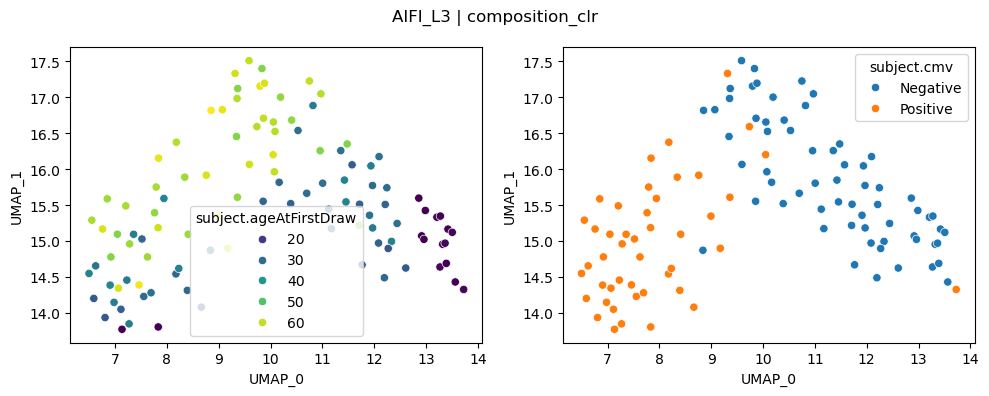

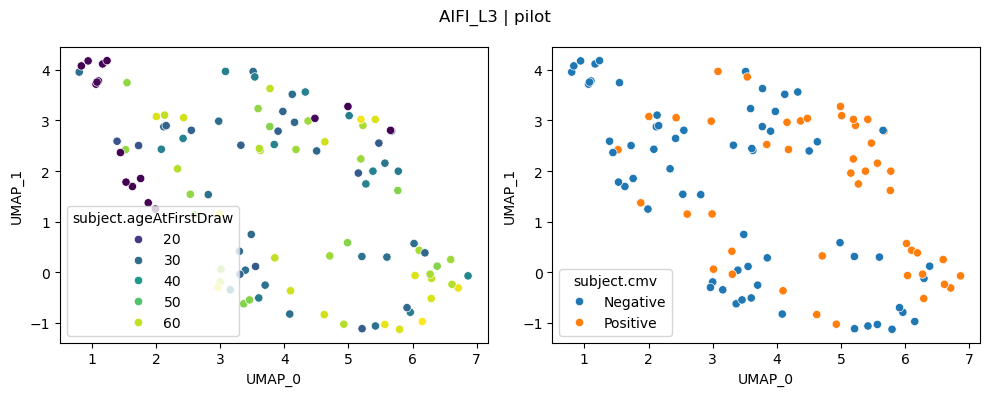

In [10]:
top2 = results.sort_values("mean_score", ascending=False).head(2)
for _, row in top2.iterrows():
    label_key = row["label_key"]
    method = row["method"]
    m = build_method(method, label_key)
    m.prepare_anndata(adata)
    m.calculate_distance_matrix(force=method.startswith("composition"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    m.plot_embedding(method="UMAP", metadata_cols=[AGE_COL, CMV_COL], axes=axes)
    fig.suptitle(f"{label_key} | {method}")
    plt.tight_layout()


We can once again see that CLR-transformed cell type compositions capture age and CMV effects clearly.

In this tutorial you learned how to use `patpy` to find patterns in cell type composition values. Note that the analysis we performed here (apart from PERMANOVA) is exploratory. For statistical testing of cell type composition differences, take a look at [scCODA](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/sccoda.html).